
# RNN vs LSTM vs GRU

## Instructions

In this lab, you will build **three text classification models** from scratch:
- RNN
- LSTM
- GRU

---

### Objectives
By the end of this lab, you should be able to:

- Preprocess text data
- Build a vocabulary
- Encode and pad sequences
- Implement RNN, LSTM, and GRU in PyTorch
- Train and evaluate models
- Compare architectures


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from datasets import load_dataset

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [8]:
import pandas as pd

df = pd.read_csv("./custom_dataset_v1_mini.csv", sep=";")
dg = pd.read_csv("./dataset-exemplos.csv", sep=";")
dh = pd.read_csv("./subm1.csv", sep=";")


In [12]:
contagens = df['Label'].value_counts()
# Número final de amostras por classe
amostras_por_classe = min(contagens)
#amostras_por_classe = int(amostras_por_classe * 0.5)  # Usar 80% das amostras para treinamento

# Gerar subconjunto
dfs = []
for classe, n in contagens.items():
    dfs.append(df[df['Label'] == classe].sample(amostras_por_classe, random_state=12345))

dfb = pd.concat(dfs, ignore_index=True)

label_map = {
    "Human": 0,
    "Anthropic": 1,
    "Google": 2,
    "OpenAI": 3,
    "Meta": 4
}

# Keep the existing `ds` creation logic unchanged, which creates `ds` from `dg`
dt = [
    {'text': row.Text, 'label': label_map[row.Label]}
    for row in dfb.itertuples(index=False)
]

# Keep the existing `ds` creation logic unchanged, which creates `ds` from `dg`
ds = [
    {'text': row.Text, 'label': label_map[row.Label]}
    for row in dg.itertuples(index=False)
]

In [13]:
import re

def temp_tokenize(text):
    """Temporary tokenization function for correlation score calculation."""
    text = text.lower()
    text = re.sub(r"<.*?>", "", text) # Remove HTML tags
    text = re.sub(r"[^a-zA-Z]", " ", text) # Replace non-alphabetic characters with spaces
    return text.split()[:120]

# 2. Extract unique words from `dg` (test dataset texts)
ds_unique_words = set()
for text in dg['Text']:
    ds_unique_words.update(temp_tokenize(text))

for text in dh['Text']:
    ds_unique_words.update(temp_tokenize(text))

# 3. Calculate a 'correlation score' for each text in the original `df` DataFrame
scored_dt_candidates = []
for index, row in df.iterrows(): # Iterate through the *original* df
    text_tokens = set(temp_tokenize(row.Text))
    correlation_score = len(text_tokens.intersection(ds_unique_words))
    scored_dt_candidates.append({
        'text': row.Text,
        'label': label_map[row.Label],
        'correlation_score': correlation_score
    })

# Convert to DataFrame for easier grouping and sorting
scored_dt_df = pd.DataFrame(scored_dt_candidates)

# 4. Filter the texts to create the final `dt` list
dt = []
# `amostras_por_classe` is defined in cell 8153be54 and should be accessible
for label_name, label_id in label_map.items():
    class_data = scored_dt_df[scored_dt_df['label'] == label_id]
    # Sort by correlation_score in descending order and select top N
    sorted_class_data = class_data.sort_values(by='correlation_score', ascending=False)
    selected_samples = sorted_class_data.head(amostras_por_classe)
    for _, row in selected_samples.iterrows():
        dt.append({'text': row.text, 'label': row.label})


In [14]:
pd.DataFrame(dt)['label'].value_counts()
#df['Label'].value_counts()

,count
label,
0,10305
1,10305
2,10305
3,10305
4,10305


In [15]:
# Reduce dataset size for faster training during class
train_data = dt
test_data = ds

print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 51525
Test size: 125



# Part 1 – Text Preprocessing

You must:

1. Write a `tokenize(text)` function.
2. Build a vocabulary using the training set only.
3. Keep only the top 10,000 most frequent words.
4. Add special tokens:
   - `<pad>`
   - `<unk>`
5. Explain in a markdown cell:
   - Why do we not build the vocabulary using the test set?


In [16]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text.split()

def clean_text(text): ## standardization
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

def build_vocab(texts, max_words = 10000): ## building the vocabulary
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    most_common = counter.most_common(max_words-2)
    vocab = {"<pad>": 0, "<unk>": 1}
    for i, (word, _) in enumerate(most_common, start=2):
        vocab[word] = i
    return vocab

max_words = 10000
word_index = build_vocab([text["text"] for text in train_data], max_words)


# Part 2 – Encoding and Padding

You must:

1. Create an `encode(text)` function.
2. Convert tokens into vocabulary indices.
3. Pad or truncate sequences to a fixed length (e.g., 25).
4. Create a custom `collate()` function.
5. Create train, validation, and test DataLoaders.

Explain:
- Why is padding necessary?
- Why should validation and test loaders not shuffle?


In [17]:
# @title
def encode(text, word_index, max_len=120): ## integer encoding
    tokens = tokenize(text)

    sequence = [word_index.get(word, 1) for word in tokens]
    # Truncate
    sequence = sequence[:max_len]
    # Pad
    if len(sequence) < max_len:
        sequence += [0] * (max_len - len(sequence))

    return torch.tensor(sequence, dtype=torch.long)

def collate(batch):
    X, y = [], []

    for item in batch:
        X.append(encode(item["text"], word_index))
        y.append(item["label"])

    return torch.stack(X), torch.tensor(y)

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

train_subset, val_subset = random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, collate_fn=collate)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=collate)



# Part 3 – Model Implementation

Create a class called `Model` that:

- Uses an Embedding layer
- Supports:
  - RNN
  - LSTM
  - GRU
- Uses multiple layers
- Applies dropout
- Outputs class logits

Your model must accept:
- model_type
- vocab_size
- embed_dim
- hidden_dim
- num_layers

Explain:
- The internal difference between RNN, LSTM, and GRU.


In [18]:
class Model(nn.Module):
    def __init__(self, model_type, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)

        if model_type == "RNN":
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers, batch_first=True)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        else:
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_dim, 5)

    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)

        out, h = self.rnn(x)

        if isinstance(h, tuple):
            h = h[0]

        # Correctly get the hidden state of the last layer for all batch items
        return self.fc(h[-1])


# Part 4 – Training Loop

Implement:

- A full training loop
- Validation loop
- Accuracy computation
- Loss tracking per epoch

Train for 10-50 epochs.

Store:
- train_loss
- val_loss
- train_accuracy
- val_accuracy

Explain:
- Why do we use `model.train()` and `model.eval()`?


In [22]:
import torch.nn as nn

def create_models(vocab_size, embed_dim, hidden_dim, num_layers, epochs=20, lr=0.001, criterion = nn.CrossEntropyLoss()):
    global modelRNN, modelLSTM, modelGRU
    global train_loss_rnn, train_acc_rnn, val_loss_rnn, val_acc_rnn
    global train_loss_lstm, train_acc_lstm, val_loss_lstm, val_acc_lstm
    global train_loss_gru, train_acc_gru, val_loss_gru, val_acc_gru

    modelRNN = Model("RNN", vocab_size, embed_dim, hidden_dim, num_layers).to(device)
    train_acc_rnn, val_acc_rnn, train_loss_rnn, val_loss_rnn = train(modelRNN, criterion, epochs, lr)

    modelLSTM = Model("LSTM ", vocab_size, embed_dim, hidden_dim, num_layers).to(device)
    train_acc_lstm, val_acc_lstm, train_loss_lstm, val_loss_lstm = train(modelLSTM, criterion, epochs, lr)

    modelGRU = Model("GRU ", vocab_size, embed_dim, hidden_dim, num_layers).to(device)
    train_acc_gru, val_acc_gru, train_loss_gru, val_loss_gru = train(modelGRU, criterion, epochs, lr)

    #modelRNN = modelLSTM = modelGRU
    #train_acc_rnn = train_acc_lstm = train_acc_gru
    #val_acc_rnn = val_acc_lstm = val_acc_gru
    #train_loss_rnn = train_loss_lstm = train_loss_gru
    #val_loss_rnn = al_loss_lstm = val_loss_gru


def train(model, criterion, epochs = 5, lr = 0.001, verbose = True):
    ## verbose - print losses and accuracies per epoch

    train_accs = []
    val_accs = []
    train_losses = []
    val_losses = []

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(model, train_loader, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        train_accs.append(train_acc)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        val_losses.append(val_loss)

        if verbose:
            print(f"Epoch {epoch+1}")
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

    return train_accs, val_accs, train_losses, val_losses

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item()

            # Corrected: Use argmax for multi-class classification
            preds = outputs.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total


In [23]:
create_models(vocab_size=max_words, embed_dim=100, hidden_dim=128, num_layers=2, epochs=10, lr=0.001)

Epoch 1
Train Loss: 1.5711, Train Acc: 0.2752
Val   Loss: 1.5741, Val   Acc: 0.2720
Epoch 2
Train Loss: 1.5512, Train Acc: 0.2914
Val   Loss: 1.5553, Val   Acc: 0.2902
Epoch 3
Train Loss: 1.5852, Train Acc: 0.2656
Val   Loss: 1.5891, Val   Acc: 0.2543
Epoch 4
Train Loss: 1.5733, Train Acc: 0.2760
Val   Loss: 1.5716, Val   Acc: 0.2779
Epoch 5
Train Loss: 1.5968, Train Acc: 0.2573
Val   Loss: 1.5996, Val   Acc: 0.2583
Epoch 6
Train Loss: 1.5049, Train Acc: 0.3022
Val   Loss: 1.5164, Val   Acc: 0.2882
Epoch 7
Train Loss: 1.4068, Train Acc: 0.3705
Val   Loss: 1.4140, Val   Acc: 0.3700
Epoch 8
Train Loss: 1.5351, Train Acc: 0.2934
Val   Loss: 1.5468, Val   Acc: 0.2809
Epoch 9
Train Loss: 1.4272, Train Acc: 0.3772
Val   Loss: 1.4407, Val   Acc: 0.3634
Epoch 10
Train Loss: 1.6172, Train Acc: 0.2781
Val   Loss: 1.6281, Val   Acc: 0.2742
Epoch 1
Train Loss: 0.8065, Train Acc: 0.6816
Val   Loss: 0.8661, Val   Acc: 0.6680
Epoch 2
Train Loss: 0.5783, Train Acc: 0.7611
Val   Loss: 0.6732, Val   Acc


# Part 5 – Model Comparison

Train:
- RNN
- LSTM
- GRU

Track validation accuracy and determine:
- Which performs best?
- Why?

Plot:
- Loss curves
- Accuracy curves

Explain signs of overfitting.


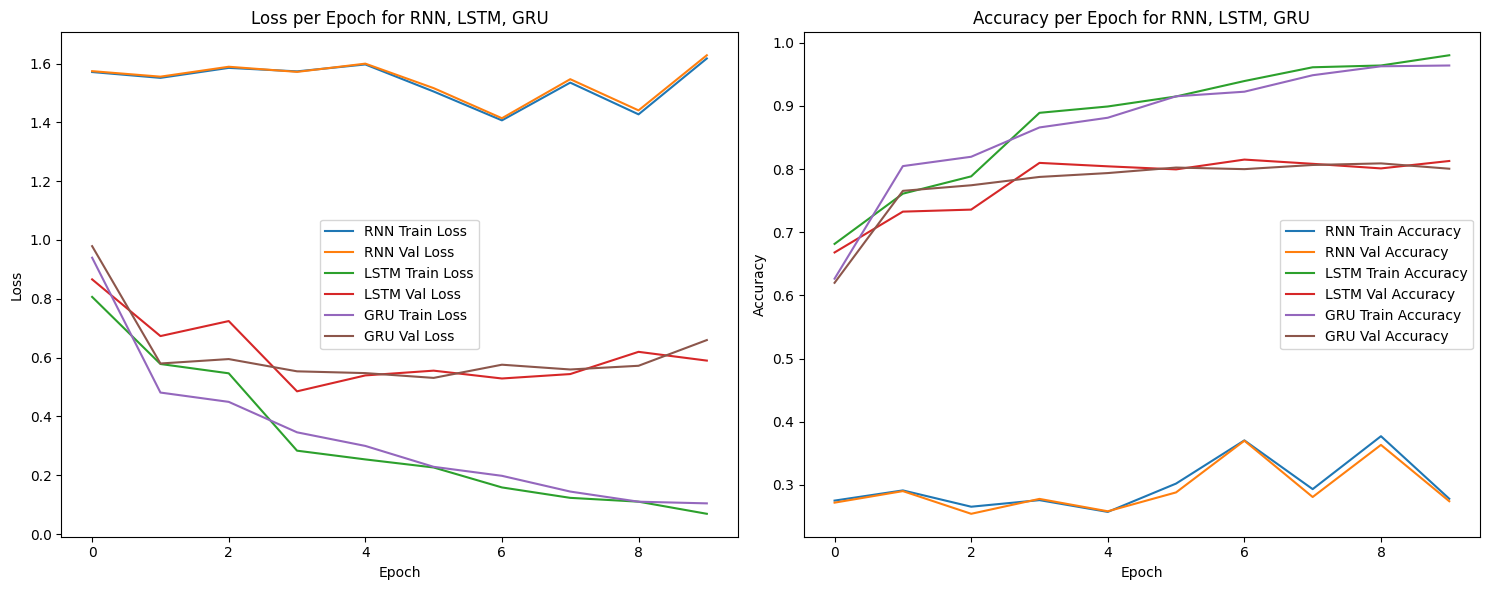

In [24]:
plt.figure(figsize=(15, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_rnn, label='RNN Train Loss')
plt.plot(val_loss_rnn, label='RNN Val Loss')
plt.plot(train_loss_lstm, label='LSTM Train Loss')
plt.plot(val_loss_lstm, label='LSTM Val Loss')
plt.plot(train_loss_gru, label='GRU Train Loss')
plt.plot(val_loss_gru, label='GRU Val Loss')
plt.title('Loss per Epoch for RNN, LSTM, GRU')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc_rnn, label='RNN Train Accuracy')
plt.plot(val_acc_rnn, label='RNN Val Accuracy')
plt.plot(train_acc_lstm, label='LSTM Train Accuracy')
plt.plot(val_acc_lstm, label='LSTM Val Accuracy')
plt.plot(train_acc_gru, label='GRU Train Accuracy')
plt.plot(val_acc_gru, label='GRU Val Accuracy')
plt.title('Accuracy per Epoch for RNN, LSTM, GRU')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


# Part 6 – Final Evaluation

Using the best model:

1. Evaluate on the test set.
2. Compute test accuracy.
3. Plot a confusion matrix.

Explain:
- Which classes are most confused?
- Why might that happen?


Best model selected based on validation accuracy: LSTM with accuracy 0.8128
Test Accuracy: 0.264


<Figure size 800x600 with 0 Axes>

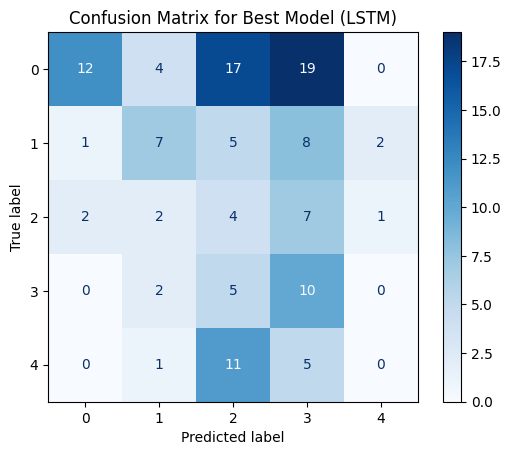

In [35]:
# Determine the best model based on validation accuracy
val_acc_scores = {
    'RNN': val_acc_rnn[-1], # Get the last validation accuracy
    'LSTM': val_acc_lstm[-1],
    'GRU': val_acc_gru[-1]
}

best_model_name = max(val_acc_scores, key=val_acc_scores.get)

if best_model_name == 'RNN':
    best_model = modelRNN
elif best_model_name == 'LSTM':
    best_model = modelLSTM
else:
    best_model = modelGRU

print(f"Best model selected based on validation accuracy: {best_model_name} with accuracy {val_acc_scores[best_model_name]:.4f}")

best_model.eval()
preds_all, labels_all = [], []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        preds = best_model(X).argmax(1)

        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(y.cpu().numpy())

acc = np.mean(np.array(preds_all) == np.array(labels_all))
print("Test Accuracy:", acc)

cm = confusion_matrix(labels_all, preds_all)

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix for Best Model ({best_model_name})')
plt.show()

# Part 7 - Gera arquivo de submissão para o melhor modelo

In [44]:
class PredictionDataset(Dataset):
    def __init__(self, data_list, word_index):
        self.data_list = data_list
        self.word_index = word_index

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        text = item['text']
        # Encode the text using the pre-defined encode function
        encoded_text = encode(text, self.word_index) # max_len is already set in encode function
        # Return only the encoded text, as we don't have true labels for prediction
        return encoded_text

dh_prepared = [{'text': row.Text, 'label': 0} for row in dh.itertuples(index=False)]
dh_dataset = PredictionDataset(dh_prepared, word_index)
dh_loader = DataLoader(dh_dataset, batch_size=32, shuffle=False)

predicted_labels_numerical = []
best_model.eval() # Set model to evaluation mode

with torch.no_grad(): # Disable gradient calculation for inference
    for encoded_texts in dh_loader:
        encoded_texts = encoded_texts.to(device)
        outputs = best_model(encoded_texts)
        preds = outputs.argmax(1) # Get the class with the highest probability
        predicted_labels_numerical.extend(preds.cpu().numpy())

reverse_label_map = {v: k for k, v in label_map.items()}
predicted_labels_string = [reverse_label_map[label_id] for label_id in predicted_labels_numerical]

submission_df = pd.DataFrame({'ID': dh['ID'], 'Text': dh['Text'], 'Label': predicted_labels_string})

submission_df.to_csv('submission.csv', index=False, sep=";")

print("Submission file 'submission.csv' created successfully.")
print(submission_df.head())


Submission file 'submission.csv' created successfully.
     ID                                               Text   Label
0  D2-1  A covalent bond is a chemical bond that involv...   Human
1  D2-2  A covalent bond forms when two atoms share one...  OpenAI
2  D2-3  A covalent bond is a type of chemical bond whe...  OpenAI
3  D2-4  A covalent bond is a chemical bond that involv...  OpenAI
4  D2-5  Driven by exciting developments in the field o...   Human


##Rotinas auxiliares

In [26]:
torch.save(best_model.state_dict(), 'best_model.pth')
print("Best model saved to 'best_model.pth'")

Best model saved to 'best_model.pth'


In [2]:
!unzip custom_dataset_v1_mini.zip

Archive:  custom_dataset_v1_mini.zip
  inflating: custom_dataset_v1_mini.csv  
